## Network Builder - Person 1
### Skill-Based Occupational Network Construction
This notebook cleans ESCO occupation-skill data, builds the occupation-skill matrix, computes Jaccard similarity, and constructs the occupational network.

## 1. Import Libraries

We begin by importing the main libraries used for data manipulation, similarity computation, network construction, and visualization.

In [1]:
import pandas as pd
import numpy as np
import itertools
from collections import defaultdict

import networkx as nx
from sklearn.metrics import pairwise_distances

## 2. Load Data

We load the ESCO occupation-skill dataset, which contains the relationships between occupations and the skills associated with them.

In [2]:
df = pd.read_csv("occupationSkillRelations_en.csv")
df.head()

,occupationUri,occupationLabel,relationType,skillType,skillUri,skillLabel
0,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,knowledge,http://data.europa.eu/esco/skill/fed5b267-73fa...,theatre techniques
1,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/05bc7677-5a64...,organise rehearsals
2,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/271a36a0-bc7a...,write risk assessment on performing arts produ...
3,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/47ed1d37-971b...,coordinate with creative departments
4,http://data.europa.eu/esco/occupation/00030d09...,technical director,essential,skill/competence,http://data.europa.eu/esco/skill/591dd514-735b...,adapt to artists' creative demands


In [3]:
df.columns.tolist()

['occupationUri',
 'occupationLabel',
 'relationType',
 'skillType',
 'skillUri',
 'skillLabel']

In [4]:
df.shape

(126051, 6)

## 3. Missing Values Check

Before constructing the network, we check whether the relevant variables contain missing values.

In [5]:
(df.isnull().sum() / len(df)) * 100

occupationUri      0.000000
occupationLabel    0.000000
relationType       0.000000
skillType          0.046806
skillUri           0.000000
skillLabel         0.000000
dtype: float64

In [6]:
df[['occupationLabel', 'skillLabel']].isnull().sum()

occupationLabel    0
skillLabel         0
dtype: int64

## 4. Data Cleaning and Preparation

We clean the dataset by keeping only the relevant variables (occupation and skills) and removing duplicate entries. This ensures that each occupation-skill relationship is represented only once before constructing the network.

In [7]:
df_clean = df[['occupationLabel', 'skillLabel']].drop_duplicates()
df_clean.head()

,occupationLabel,skillLabel
0,technical director,theatre techniques
1,technical director,organise rehearsals
2,technical director,write risk assessment on performing arts produ...
3,technical director,coordinate with creative departments
4,technical director,adapt to artists' creative demands


In [8]:
df_clean.shape

(126051, 2)

## 5. Occupation-Skill Matrix Construction

We construct a binary matrix where rows represent occupations and columns represent skills. A value of 1 indicates that an occupation requires a given skill.

In [9]:
matrix = pd.crosstab(df_clean['occupationLabel'], df_clean['skillLabel'])
matrix.iloc[:5, :5]

skillLabel,3D body scanning technologies,3D lighting,3D modelling,3D printing process,3D texturing
occupationLabel,,,,,
3D animator,0,1,0,0,1
3D modeller,0,1,0,1,1
3D printing technician,0,0,1,1,0
ATM repair technician,0,0,0,0,0
EU funds manager,0,0,0,0,0


In [10]:
matrix.shape

(3039, 13475)

## 6. Jaccard Similarity Computation

We compute similarity between occupations using the Jaccard index. This measure captures the proportion of shared skills between two occupations relative to the total number of skills they possess.

Higher similarity implies that two occupations require similar skill sets and therefore represent more feasible transitions.

In [24]:
# Convert matrix to binary (True/False)
binary_matrix = matrix.astype(bool)

# Convert to numpy array
binary_array = binary_matrix.to_numpy()

# Compute Jaccard distance
jaccard_dist = pairwise_distances(binary_array, metric='jaccard')

# Convert distance to similarity
jaccard_sim = 1 - jaccard_dist

# Check result
print(jaccard_sim.shape)

(3039, 3039)


## 7. Network Construction

We construct a network where nodes represent occupations and edges connect occupations with similarity above a given threshold τ. This allows us to focus on meaningful transitions between occupations.

In [27]:
# Set threshold
threshold = 0.3
occ_labels = matrix.index.tolist()

# Build weighted graph with occupation labels as node names
G = nx.Graph()
G.add_nodes_from(occ_labels)

rows, cols = np.where(jaccard_sim > threshold)
for r, c in zip(rows, cols):
    if r < c:  # avoid duplicates and self-loops
        G.add_edge(occ_labels[r], occ_labels[c], weight=jaccard_sim[r, c])

print("Number of nodes:", G.number_of_nodes())
print("Number of edges:", G.number_of_edges())

Number of nodes: 3039
Number of edges: 14103


## 8.Network Visualization

Because the full occupational network is too large to visualize clearly, we display a reduced subgraph from the largest connected component. This provides an interpretable illustration of the structure generated by the selected threshold.

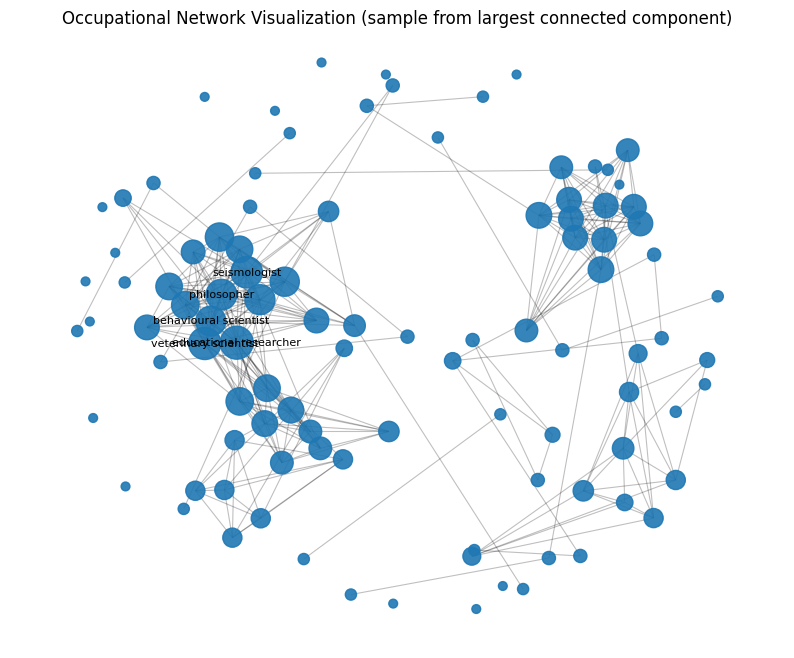

In [28]:
import matplotlib.pyplot as plt
import networkx as nx

# Extract largest connected component
largest_cc_nodes = max(nx.connected_components(G), key=len)
G_lcc = G.subgraph(largest_cc_nodes).copy()

# Take a sample of 100 nodes
sample_nodes = list(G_lcc.nodes())[:100]
G_vis = G_lcc.subgraph(sample_nodes).copy()

# Degree-based node sizes
degrees = dict(G_vis.degree())
node_sizes = [degrees[n] * 25 + 40 for n in G_vis.nodes()]

# Label top 5 nodes
top_nodes = sorted(degrees, key=degrees.get, reverse=True)[:5]
labels = {n: n for n in top_nodes}

# Layout
pos = nx.spring_layout(G_vis, seed=42, k=0.5)

# Plot
plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G_vis, pos, alpha=0.25, width=0.8)
nx.draw_networkx_nodes(G_vis, pos, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G_vis, pos, labels=labels, font_size=8)

plt.title("Occupational Network Visualization (sample from largest connected component)")
plt.axis("off")
plt.show()

## 9. Threshold Sensitivity Analysis

To validate the network construction, we analyze how different similarity thresholds affect the structure of the occupational network. Lower thresholds produce denser networks, while higher thresholds retain only stronger and more meaningful connections.

This analysis helps justify the choice of the threshold used in the main network.

In [29]:
thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

results = []

for tau in thresholds:
    adj_tau = (jaccard_sim > tau).astype(int)
    np.fill_diagonal(adj_tau, 0)

    G_tau = nx.from_numpy_array(adj_tau)

    n_edges = G_tau.number_of_edges()
    density = nx.density(G_tau)
    n_components = nx.number_connected_components(G_tau)
    largest_cc = max(nx.connected_components(G_tau), key=len)
    largest_cc_size = len(largest_cc)

    results.append({
        "threshold": tau,
        "edges": n_edges,
        "density": density,
        "n_components": n_components,
        "largest_component_size": largest_cc_size
    })

results_df = pd.DataFrame(results)
results_df

,threshold,edges,density,n_components,largest_component_size
0,0.1,66870,0.014486,50,2977
1,0.2,28813,0.006242,445,1751
2,0.3,14103,0.003055,1025,416
3,0.4,8635,0.001871,1627,84
4,0.5,6412,0.001389,2044,44


## 10. Threshold Sensitivity Plot

We visualize how the size of the largest connected component changes as the similarity threshold increases.

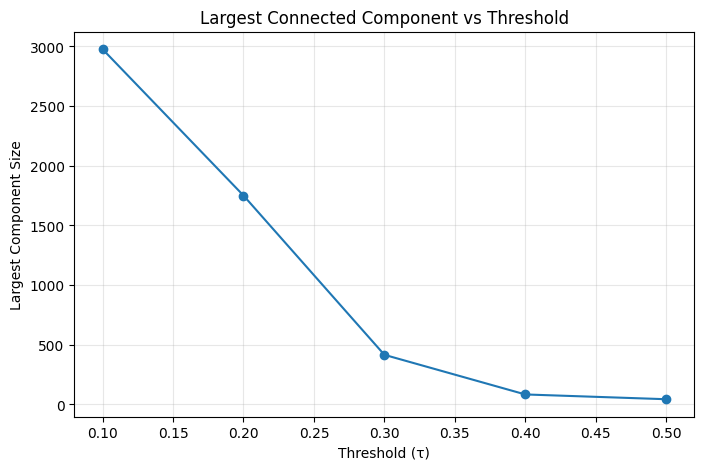

In [21]:
plt.figure(figsize=(8,5))
plt.plot(results_df["threshold"], results_df["largest_component_size"], marker="o")
plt.title("Largest Connected Component vs Threshold")
plt.xlabel("Threshold (τ)")
plt.ylabel("Largest Component Size")
plt.grid(True, alpha=0.3)
plt.show()



The threshold sensitivity analysis shows that lower thresholds produce highly connected networks, while higher thresholds lead to fragmented structures.

At τ = 0.1, almost all occupations belong to a single large connected component, indicating excessive connectivity and potential noise. As the threshold increases, the size of the largest connected component decreases significantly, reflecting a more selective network.

At τ = 0.3, the network maintains a meaningful level of connectivity while avoiding excessive density. Higher thresholds (τ ≥ 0.4) result in very fragmented networks, with only small isolated groups of occupations.

Therefore, we select τ = 0.3 as a balance between capturing meaningful occupational similarities and avoiding overly dense or disconnected networks. This choice ensures that the resulting network captures realistic occupational transitions based on shared skills.

In [30]:
# Export threshold sensitivity results
results_df.to_csv("threshold_sensitivity_results.csv", index=False)

# Export Jaccard similarity matrix
pd.DataFrame(jaccard_sim, index=matrix.index, columns=matrix.index).to_csv("jaccard_similarity_matrix.csv")

# Export network edges with weights
nx.write_graphml(G, "occupational_network_tau03.graphml")

## Summary

In this section, we cleaned the ESCO data, constructed the occupation-skill matrix, computed occupational similarity using the Jaccard index, built the occupational network, and justified the selection of the threshold used in the main analysis.